In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error,
    classification_report, confusion_matrix
)

print("All libraries imported!")

All libraries imported!


## Load and Explore Data

In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/impremmohan/global-ai-research-papers-2020-2026/global_ai_research_papers_2020_2026.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (10000, 12)

First 5 rows:


,paper_id,title,published_year,published_month,first_author,authors_count,primary_category,all_categories,abstract_length,word_count,journal_ref,pdf_url
0,2603.13228v1,PhysMoDPO: Physically-Plausible Humanoid Motio...,2026,3,Yangsong Zhang,8,cs.LG,"cs.LG, cs.AI, cs.CV, cs.RO",1369,186,Not Published,https://arxiv.org/abs/2603.13228v1
1,2603.13227v1,Representation Learning for Spatiotemporal Phy...,2026,3,Helen Qu,7,cs.LG,"cs.LG, cs.CV",1232,160,Not Published,https://arxiv.org/abs/2603.13227v1
2,2603.13224v1,Visual-ERM: Reward Modeling for Visual Equival...,2026,3,Ziyu Liu,10,cs.CV,"cs.CV, cs.AI",1441,182,Not Published,https://arxiv.org/abs/2603.13224v1
3,2603.13191v1,From Experiments to Expertise: Scientific Know...,2026,3,Haonan Huang,1,physics.comp-ph,"physics.comp-ph, cond-mat.mtrl-sci, cs.AI",1120,146,Not Published,https://arxiv.org/abs/2603.13191v1
4,2603.13189v1,LLM Constitutional Multi-Agent Governance,2026,3,J. de Curtò,2,cs.MA,"cs.MA, cs.AI",1859,238,Not Published,https://arxiv.org/abs/2603.13189v1


## Data Cleaning and Pre Processing 

In [3]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Check data types
print("\nData Types:\n")
print(df.dtypes)

# Basic statistics
print("\nBasic Statistics:\n")
df.describe()

Missing Values:

paper_id            0
title               0
published_year      0
published_month     0
first_author        0
authors_count       0
primary_category    0
all_categories      0
abstract_length     0
word_count          0
journal_ref         0
pdf_url             0
dtype: int64

Data Types:

paper_id            object
title               object
published_year       int64
published_month      int64
first_author        object
authors_count        int64
primary_category    object
all_categories      object
abstract_length      int64
word_count           int64
journal_ref         object
pdf_url             object
dtype: object

Basic Statistics:



,published_year,published_month,authors_count,abstract_length,word_count
count,10000.0,10000.000000,10000.00000,10000.000000,10000.00000
mean,2026.0,2.300200,5.12380,1334.882000,175.93320
std,0.0,0.458368,5.97316,293.212099,39.08889
min,2026.0,2.000000,1.00000,228.000000,32.00000
25%,2026.0,2.000000,3.00000,1133.000000,149.00000
50%,2026.0,2.000000,4.00000,1332.000000,175.00000
75%,2026.0,3.000000,6.00000,1536.000000,202.00000
max,2026.0,3.000000,326.00000,1924.000000,298.00000


## Feature Engineering 

In [4]:
# Create useful features for ML

# 1. Encode primary_category
le_category = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['primary_category'])

# 2. Create target variable for classification
# Papers with more than 5 authors = "Collaborative" else "Individual"
df['research_type'] = df['authors_count'].apply(
    lambda x: 'Collaborative' if x > 5 else 'Individual'
)

# 3. Encode research_type
le_research = LabelEncoder()
df['research_type_encoded'] = le_research.fit_transform(df['research_type'])

# 4. Create abstract complexity
df['abstract_complexity'] = df['abstract_length'] / (df['word_count'] + 1)

print("✅ Feature Engineering Done!")
print(f"\nNew Columns: {['category_encoded', 'research_type', 'research_type_encoded', 'abstract_complexity']}")

df.head()

✅ Feature Engineering Done!

New Columns: ['category_encoded', 'research_type', 'research_type_encoded', 'abstract_complexity']


,paper_id,title,published_year,published_month,first_author,authors_count,primary_category,all_categories,abstract_length,word_count,journal_ref,pdf_url,category_encoded,research_type,research_type_encoded,abstract_complexity
0,2603.13228v1,PhysMoDPO: Physically-Plausible Humanoid Motio...,2026,3,Yangsong Zhang,8,cs.LG,"cs.LG, cs.AI, cs.CV, cs.RO",1369,186,Not Published,https://arxiv.org/abs/2603.13228v1,30,Collaborative,0,7.320856
1,2603.13227v1,Representation Learning for Spatiotemporal Phy...,2026,3,Helen Qu,7,cs.LG,"cs.LG, cs.CV",1232,160,Not Published,https://arxiv.org/abs/2603.13227v1,30,Collaborative,0,7.652174
2,2603.13224v1,Visual-ERM: Reward Modeling for Visual Equival...,2026,3,Ziyu Liu,10,cs.CV,"cs.CV, cs.AI",1441,182,Not Published,https://arxiv.org/abs/2603.13224v1,16,Collaborative,0,7.874317
3,2603.13191v1,From Experiments to Expertise: Scientific Know...,2026,3,Haonan Huang,1,physics.comp-ph,"physics.comp-ph, cond-mat.mtrl-sci, cs.AI",1120,146,Not Published,https://arxiv.org/abs/2603.13191v1,78,Individual,1,7.619048
4,2603.13189v1,LLM Constitutional Multi-Agent Governance,2026,3,J. de Curtò,2,cs.MA,"cs.MA, cs.AI",1859,238,Not Published,https://arxiv.org/abs/2603.13189v1,32,Individual,1,7.778243


## EDA Visualizations

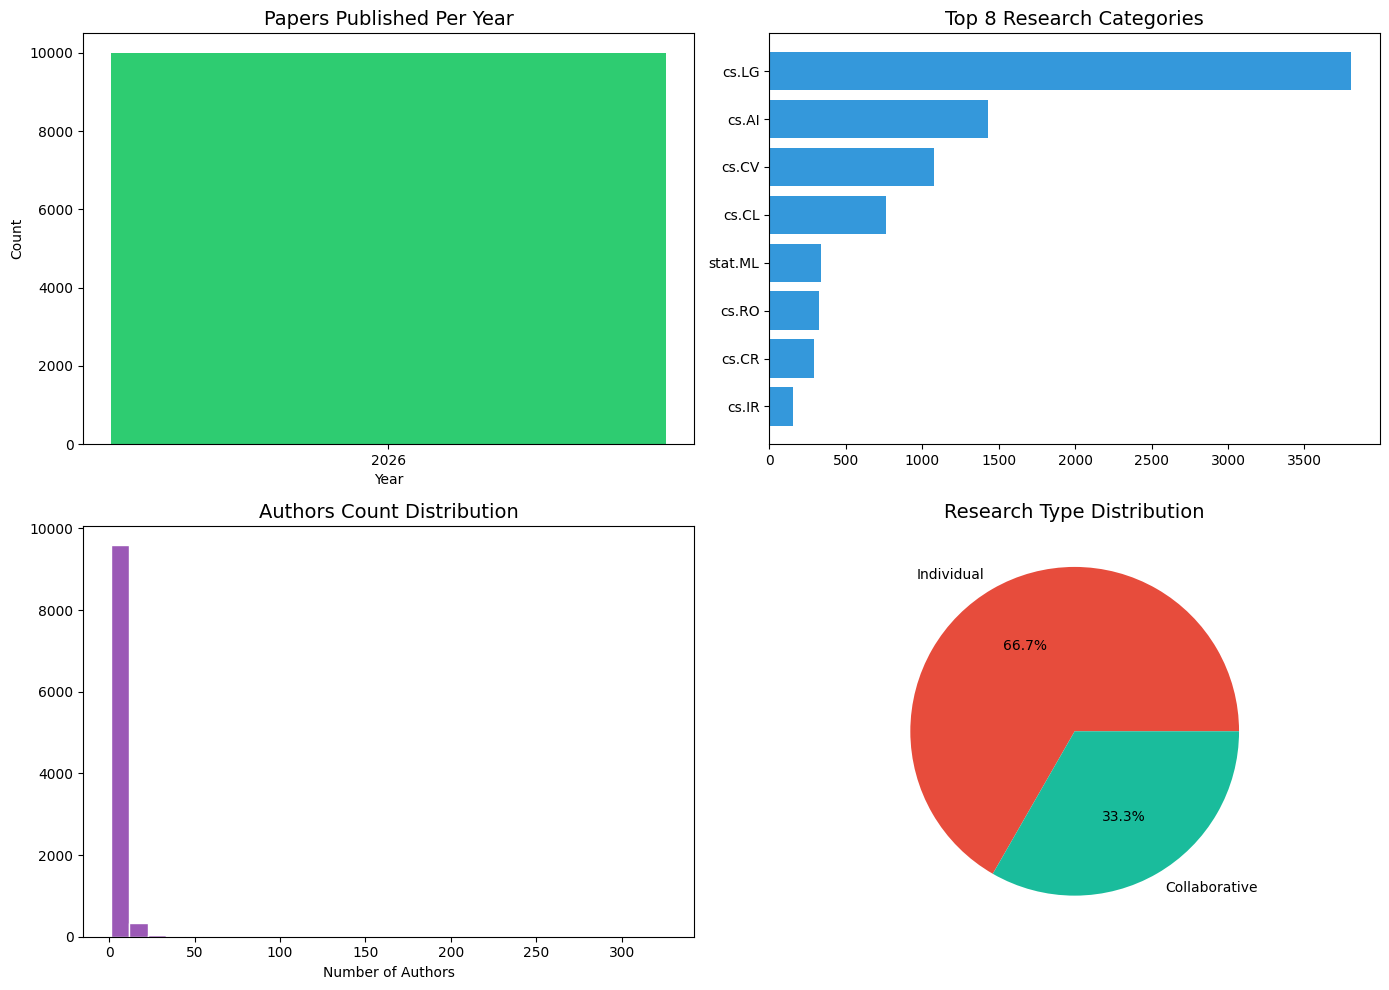

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Papers Per Year
year_counts = df['published_year'].value_counts().sort_index()
axes[0,0].bar(year_counts.index.astype(str), year_counts.values, color='#2ecc71')
axes[0,0].set_title('Papers Published Per Year', fontsize=14)
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Count')

# Plot 2: Top Categories
top_cats = df['primary_category'].value_counts().head(8)
axes[0,1].barh(top_cats.index, top_cats.values, color='#3498db')
axes[0,1].set_title('Top 8 Research Categories', fontsize=14)
axes[0,1].invert_yaxis()

# Plot 3: Authors Count Distribution
axes[1,0].hist(df['authors_count'], bins=30, color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Authors Count Distribution', fontsize=14)
axes[1,0].set_xlabel('Number of Authors')

# Plot 4: Research Type Distribution
research_counts = df['research_type'].value_counts()
axes[1,1].pie(research_counts.values, labels=research_counts.index,
              autopct='%1.1f%%', colors=['#e74c3c', '#1abc9c'])
axes[1,1].set_title('Research Type Distribution', fontsize=14)

plt.tight_layout()
plt.show()

## Prepare Data for ML

In [6]:

# REGRESSION: Predict word_count

X_reg = df[['authors_count', 'abstract_length', 'category_encoded', 'abstract_complexity']]
y_reg = df['word_count']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# CLASSIFICATION: Predict research_type

X_clf = df[['word_count', 'abstract_length', 'category_encoded', 'abstract_complexity']]
y_clf = df['research_type_encoded']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_clf_train_scaled = scaler.fit_transform(X_clf_train)
X_clf_test_scaled = scaler.transform(X_clf_test)

print("Data split complete!")
print(f"Regression - Train: {X_reg_train.shape}, Test: {X_reg_test.shape}")
print(f"Classification - Train: {X_clf_train.shape}, Test: {X_clf_test.shape}")

Data split complete!
Regression - Train: (8000, 4), Test: (2000, 4)
Classification - Train: (8000, 4), Test: (2000, 4)


## Linear Regression

PART 1: LINEAR REGRESSION

Mean Absolute Error (MAE):  1.62
Mean Squared Error (MSE):   6.44
Root Mean Squared Error:    2.54


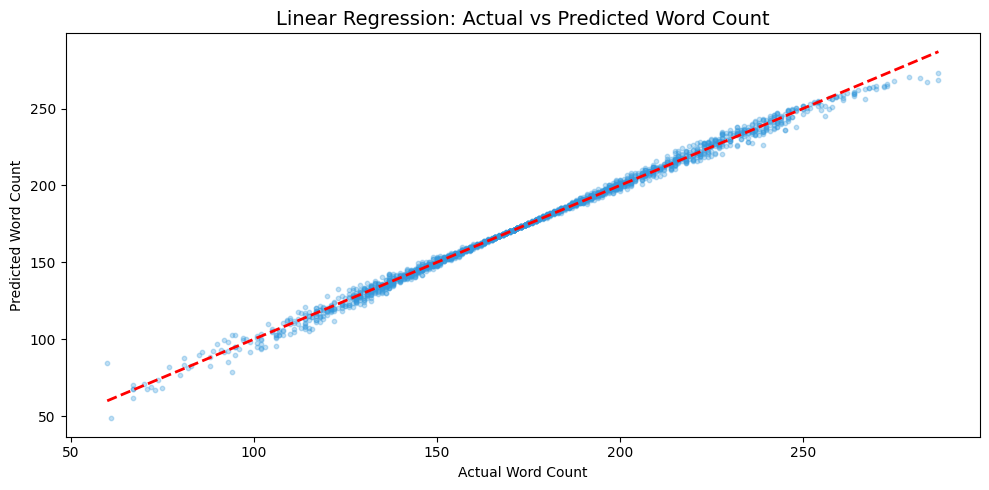

In [7]:
print("=" * 60)
print("PART 1: LINEAR REGRESSION")
print("=" * 60)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_reg_train, y_reg_train)

# Predict
y_reg_pred = lr_model.predict(X_reg_test)

# Metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)

print(f"\nMean Absolute Error (MAE):  {mae:.2f}")
print(f"Mean Squared Error (MSE):   {mse:.2f}")
print(f"Root Mean Squared Error:    {rmse:.2f}")

# MAE: Average prediction is off by this many words
# MSE: Penalizes larger errors more heavily
# RMSE: Same unit as target, easier to interpret

# Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.3, color='#3498db', s=10)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         'r--', linewidth=2)
plt.title('Linear Regression: Actual vs Predicted Word Count', fontsize=14)
plt.xlabel('Actual Word Count')
plt.ylabel('Predicted Word Count')
plt.tight_layout()
plt.show()

## Logistic Regression 

In [8]:
print("=" * 60)
print("PART 2: LOGISTIC REGRESSION")
print("=" * 60)

# Train model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_clf_train_scaled, y_clf_train)

# Predict
y_log_pred = log_model.predict(X_clf_test_scaled)

# Metrics
print(f"\nAccuracy:  {accuracy_score(y_clf_test, y_log_pred):.4f}")
print(f"Precision: {precision_score(y_clf_test, y_log_pred):.4f}")
print(f"Recall:    {recall_score(y_clf_test, y_log_pred):.4f}")
print(f"F1 Score:  {f1_score(y_clf_test, y_log_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_clf_test, y_log_pred,
      target_names=['Individual', 'Collaborative']))

PART 2: LOGISTIC REGRESSION

Accuracy:  0.6630
Precision: 0.6679
Recall:    0.9789
F1 Score:  0.7940

Classification Report:
               precision    recall  f1-score   support

   Individual       0.49      0.04      0.07       673
Collaborative       0.67      0.98      0.79      1327

     accuracy                           0.66      2000
    macro avg       0.58      0.51      0.43      2000
 weighted avg       0.61      0.66      0.55      2000



## Naive Bayes 

In [9]:
print("=" * 60)
print("PART 3: NAIVE BAYES (GaussianNB)")
print("=" * 60)

# Train model
nb_model = GaussianNB()
nb_model.fit(X_clf_train_scaled, y_clf_train)

# Predict
y_nb_pred = nb_model.predict(X_clf_test_scaled)

# Metrics
print(f"\nAccuracy:  {accuracy_score(y_clf_test, y_nb_pred):.4f}")
print(f"Precision: {precision_score(y_clf_test, y_nb_pred):.4f}")
print(f"Recall:    {recall_score(y_clf_test, y_nb_pred):.4f}")
print(f"F1 Score:  {f1_score(y_clf_test, y_nb_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_clf_test, y_nb_pred,
      target_names=['Individual', 'Collaborative']))

PART 3: NAIVE BAYES (GaussianNB)

Accuracy:  0.6420
Precision: 0.6915
Recall:    0.8312
F1 Score:  0.7550

Classification Report:
               precision    recall  f1-score   support

   Individual       0.45      0.27      0.34       673
Collaborative       0.69      0.83      0.75      1327

     accuracy                           0.64      2000
    macro avg       0.57      0.55      0.55      2000
 weighted avg       0.61      0.64      0.61      2000



## KNN (3 Different K Values)

PART 4: K-NEAREST NEIGHBORS (KNN)
K = 3  →  Accuracy: 0.6040
K = 5  →  Accuracy: 0.6250
K = 7  →  Accuracy: 0.6350
K = 9  →  Accuracy: 0.6405
K = 11  →  Accuracy: 0.6430

✅ Best K = 11 with Accuracy = 0.6430


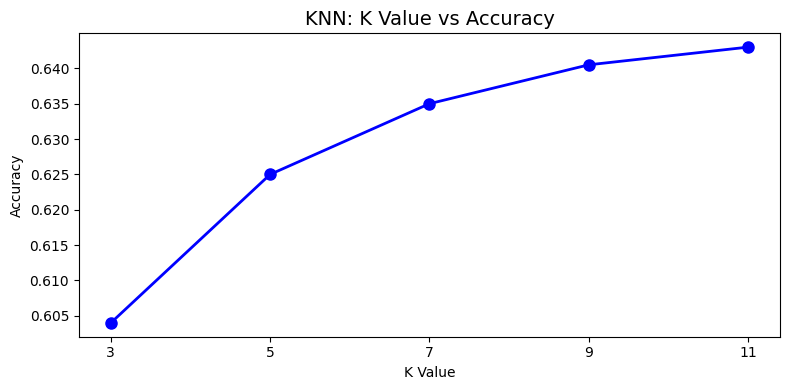


Classification Report (K=11):
               precision    recall  f1-score   support

   Individual       0.44      0.22      0.29       673
Collaborative       0.68      0.86      0.76      1327

     accuracy                           0.64      2000
    macro avg       0.56      0.54      0.53      2000
 weighted avg       0.60      0.64      0.60      2000



In [10]:
print("=" * 60)
print("PART 4: K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)

k_values = [3, 5, 7, 9, 11]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_clf_train_scaled, y_clf_train)
    y_knn_pred = knn.predict(X_clf_test_scaled)
    acc = accuracy_score(y_clf_test, y_knn_pred)
    knn_results.append(acc)
    print(f"K = {k}  →  Accuracy: {acc:.4f}")

# Best K
best_k = k_values[np.argmax(knn_results)]
print(f"\n✅ Best K = {best_k} with Accuracy = {max(knn_results):.4f}")

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_values, knn_results, 'bo-', linewidth=2, markersize=8)
plt.title('KNN: K Value vs Accuracy', fontsize=14)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# Best KNN Report
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_clf_train_scaled, y_clf_train)
y_best_knn_pred = best_knn.predict(X_clf_test_scaled)

print(f"\nClassification Report (K={best_k}):")
print(classification_report(y_clf_test, y_best_knn_pred,
      target_names=['Individual', 'Collaborative']))

## Decision Tree

PART 5: DECISION TREE

Accuracy:  0.6460
Precision: 0.6778
Recall:    0.8892
F1 Score:  0.7692


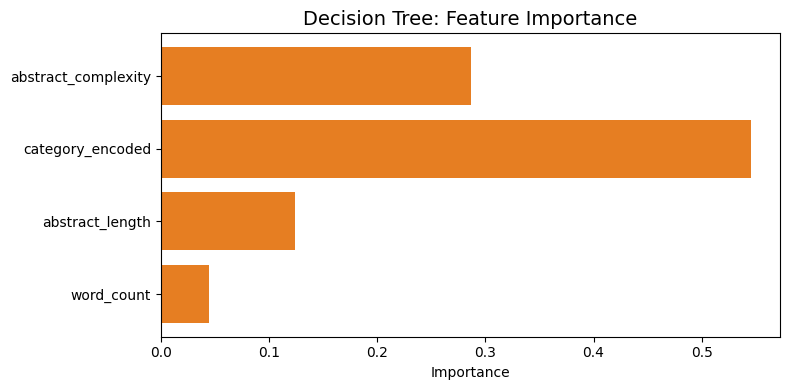

In [11]:
print("=" * 60)
print("PART 5: DECISION TREE")
print("=" * 60)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_clf_train, y_clf_train)

y_dt_pred = dt_model.predict(X_clf_test)

print(f"\nAccuracy:  {accuracy_score(y_clf_test, y_dt_pred):.4f}")
print(f"Precision: {precision_score(y_clf_test, y_dt_pred):.4f}")
print(f"Recall:    {recall_score(y_clf_test, y_dt_pred):.4f}")
print(f"F1 Score:  {f1_score(y_clf_test, y_dt_pred):.4f}")

# Feature Importance
plt.figure(figsize=(8, 4))
importance = dt_model.feature_importances_
features = X_clf.columns
plt.barh(features, importance, color='#e67e22')
plt.title('Decision Tree: Feature Importance', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Random Forest

In [12]:
print("=" * 60)
print("PART 6: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_clf_train, y_clf_train)

y_rf_pred = rf_model.predict(X_clf_test)

print(f"\nAccuracy:  {accuracy_score(y_clf_test, y_rf_pred):.4f}")
print(f"Precision: {precision_score(y_clf_test, y_rf_pred):.4f}")
print(f"Recall:    {recall_score(y_clf_test, y_rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_clf_test, y_rf_pred):.4f}")

PART 6: RANDOM FOREST

Accuracy:  0.6590
Precision: 0.6662
Recall:    0.9744
F1 Score:  0.7913


## Support Vector Machine (SVM)

In [13]:
print("=" * 60)
print("PART 7: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_clf_train_scaled, y_clf_train)

y_svm_pred = svm_model.predict(X_clf_test_scaled)

print(f"\nAccuracy:  {accuracy_score(y_clf_test, y_svm_pred):.4f}")
print(f"Precision: {precision_score(y_clf_test, y_svm_pred):.4f}")
print(f"Recall:    {recall_score(y_clf_test, y_svm_pred):.4f}")
print(f"F1 Score:  {f1_score(y_clf_test, y_svm_pred):.4f}")

PART 7: SUPPORT VECTOR MACHINE (SVM)

Accuracy:  0.6635
Precision: 0.6635
Recall:    1.0000
F1 Score:  0.7977


## Compare - All Models 

FINAL COMPARISON: ALL MODELS


              Model  Accuracy  Precision  Recall  F1 Score
                SVM    0.6635     0.6635  1.0000    0.7977
Logistic Regression    0.6630     0.6679  0.9789    0.7940
      Random Forest    0.6590     0.6662  0.9744    0.7913
      Decision Tree    0.6460     0.6778  0.8892    0.7692
         KNN (K=11)    0.6430     0.6843  0.8576    0.7612
        Naive Bayes    0.6420     0.6915  0.8312    0.7550


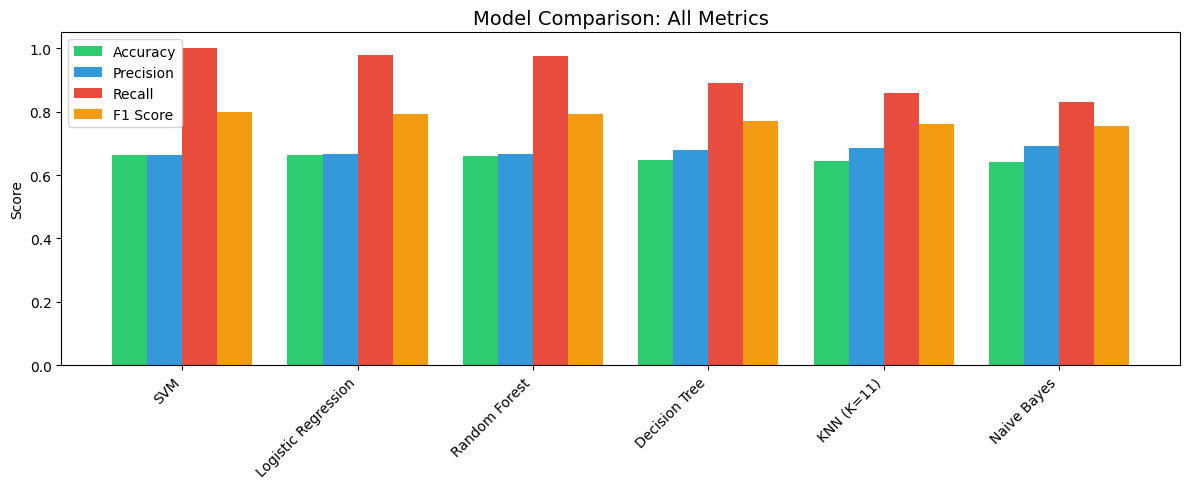


 Best Model: SVM with Accuracy: 0.6635


In [14]:
print("=" * 60)
print("FINAL COMPARISON: ALL MODELS")
print("=" * 60)

models = {
    'Logistic Regression': y_log_pred,
    'Naive Bayes': y_nb_pred,
    f'KNN (K={best_k})': y_best_knn_pred,
    'Decision Tree': y_dt_pred,
    'Random Forest': y_rf_pred,
    'SVM': y_svm_pred
}

results = []
for name, pred in models.items():
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_clf_test, pred), 4),
        'Precision': round(precision_score(y_clf_test, pred), 4),
        'Recall': round(recall_score(y_clf_test, pred), 4),
        'F1 Score': round(f1_score(y_clf_test, pred), 4)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n")
print(results_df.to_string(index=False))

# Plot comparison
plt.figure(figsize=(12, 5))
x = range(len(results_df))
width = 0.2

plt.bar([i-0.3 for i in x], results_df['Accuracy'], width, label='Accuracy', color='#2ecc71')
plt.bar([i-0.1 for i in x], results_df['Precision'], width, label='Precision', color='#3498db')
plt.bar([i+0.1 for i in x], results_df['Recall'], width, label='Recall', color='#e74c3c')
plt.bar([i+0.3 for i in x], results_df['F1 Score'], width, label='F1 Score', color='#f39c12')

plt.xticks(x, results_df['Model'], rotation=45, ha='right')
plt.title('Model Comparison: All Metrics', fontsize=14)
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

# Best Model
best = results_df.iloc[0]
print(f"\n Best Model: {best['Model']} with Accuracy: {best['Accuracy']}")

## Decision Matrices

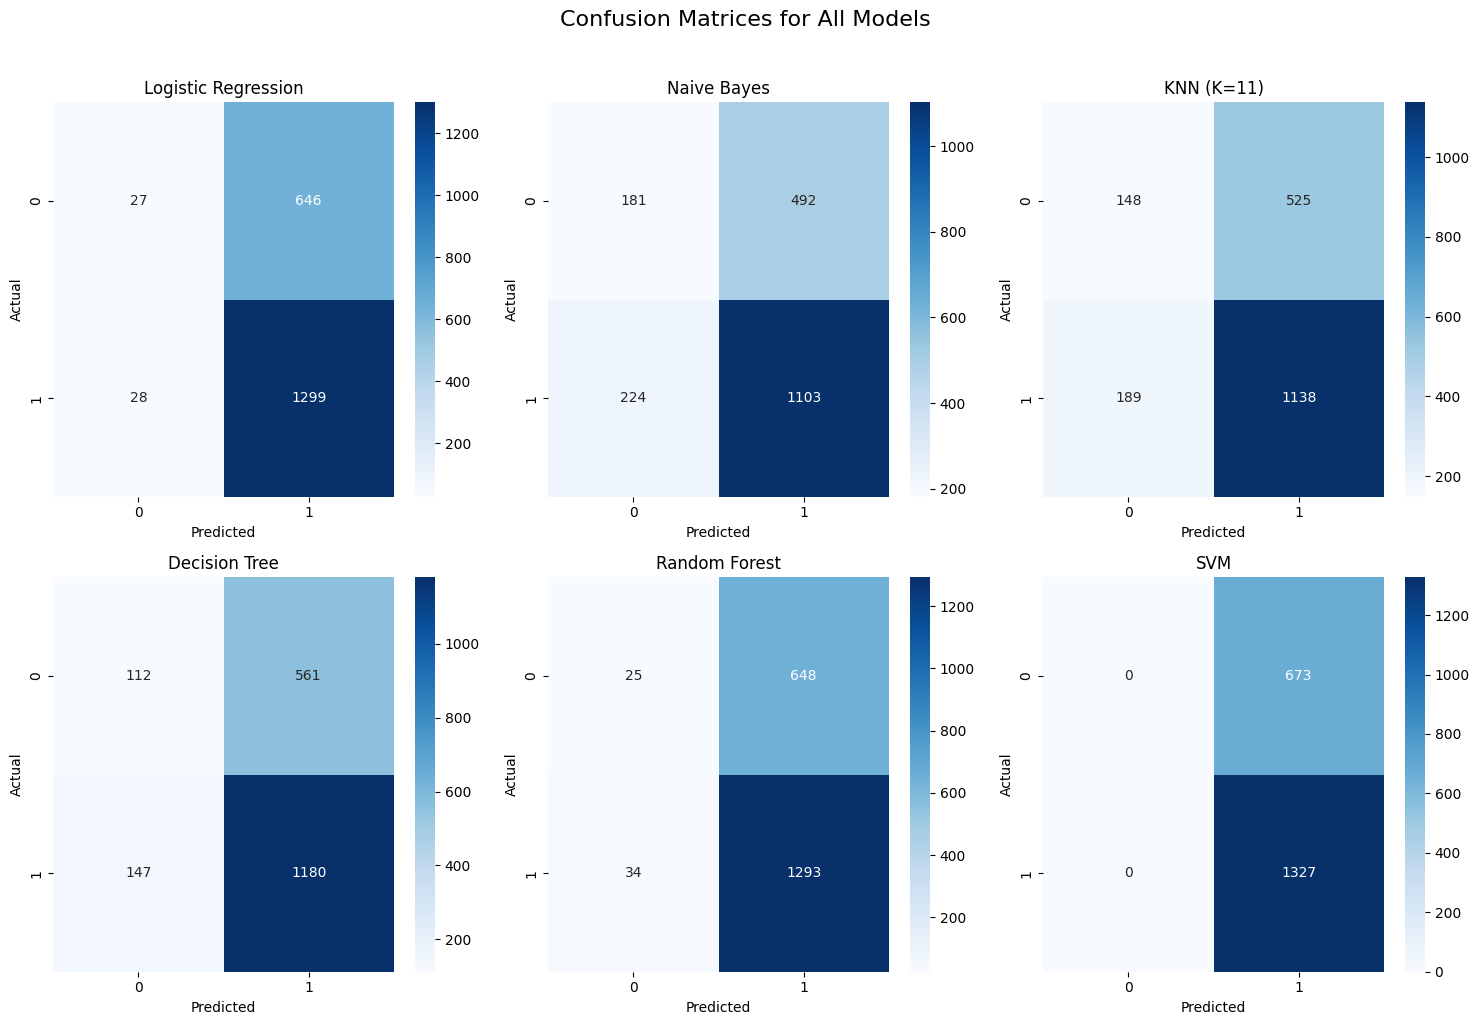

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, pred) in enumerate(models.items()):
    cm = confusion_matrix(y_clf_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}', fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices for All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Overfitting vs Underfitting

PART 10: OVERFITTING vs UNDERFITTING

Underfitting (max_depth=1):
  Train Accuracy: 0.6679
  Test Accuracy:  0.6635

Overfitting (max_depth=None):
  Train Accuracy: 0.9900
  Test Accuracy:  0.5710

Balanced (max_depth=5):
  Train Accuracy: 0.6803
  Test Accuracy:  0.6460


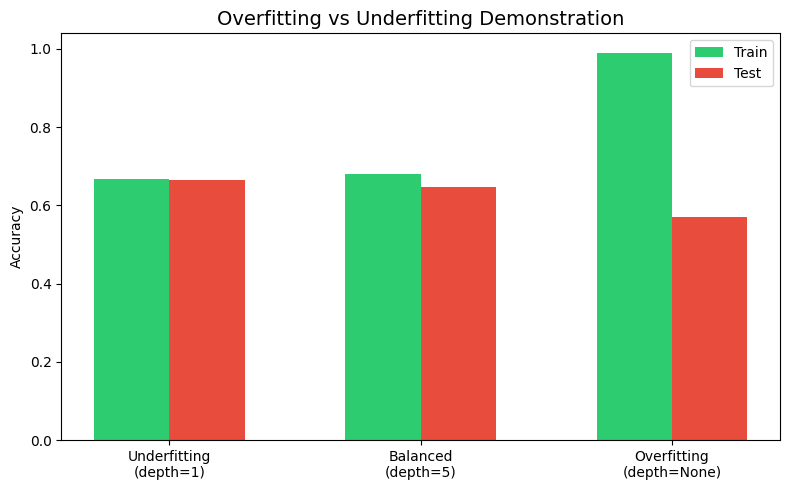

In [16]:
print("=" * 60)
print("PART 10: OVERFITTING vs UNDERFITTING")
print("=" * 60)

# Underfitting: Very simple model
simple_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
simple_tree.fit(X_clf_train, y_clf_train)
simple_train_acc = accuracy_score(y_clf_train, simple_tree.predict(X_clf_train))
simple_test_acc = accuracy_score(y_clf_test, simple_tree.predict(X_clf_test))

# Overfitting: Very complex model
complex_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
complex_tree.fit(X_clf_train, y_clf_train)
complex_train_acc = accuracy_score(y_clf_train, complex_tree.predict(X_clf_train))
complex_test_acc = accuracy_score(y_clf_test, complex_tree.predict(X_clf_test))

# Balanced model
balanced_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
balanced_tree.fit(X_clf_train, y_clf_train)
balanced_train_acc = accuracy_score(y_clf_train, balanced_tree.predict(X_clf_train))
balanced_test_acc = accuracy_score(y_clf_test, balanced_tree.predict(X_clf_test))

print("\nUnderfitting (max_depth=1):")
print(f"  Train Accuracy: {simple_train_acc:.4f}")
print(f"  Test Accuracy:  {simple_test_acc:.4f}")

print("\nOverfitting (max_depth=None):")
print(f"  Train Accuracy: {complex_train_acc:.4f}")
print(f"  Test Accuracy:  {complex_test_acc:.4f}")

print("\nBalanced (max_depth=5):")
print(f"  Train Accuracy: {balanced_train_acc:.4f}")
print(f"  Test Accuracy:  {balanced_test_acc:.4f}")

# Plot
labels = ['Underfitting\n(depth=1)', 'Balanced\n(depth=5)', 'Overfitting\n(depth=None)']
train_accs = [simple_train_acc, balanced_train_acc, complex_train_acc]
test_accs = [simple_test_acc, balanced_test_acc, complex_test_acc]

x = range(len(labels))
plt.figure(figsize=(8, 5))
plt.bar([i-0.15 for i in x], train_accs, 0.3, label='Train', color='#2ecc71')
plt.bar([i+0.15 for i in x], test_accs, 0.3, label='Test', color='#e74c3c')
plt.xticks(x, labels)
plt.title('Overfitting vs Underfitting Demonstration', fontsize=14)
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Install joblib - create model

In [17]:
import joblib
import os

# Create output directory
os.makedirs('/kaggle/working/ai_research_model', exist_ok=True)

print("Ready to save models!")

Ready to save models!


## Save All Models

In [18]:

# Save all trained models


# 1. Linear Regression
joblib.dump(lr_model, '/kaggle/working/ai_research_model/linear_regression.joblib')

# 2. Logistic Regression
joblib.dump(log_model, '/kaggle/working/ai_research_model/logistic_regression.joblib')

# 3. Naive Bayes
joblib.dump(nb_model, '/kaggle/working/ai_research_model/naive_bayes.joblib')

# 4. Best KNN
joblib.dump(best_knn, '/kaggle/working/ai_research_model/knn_model.joblib')

# 5. Decision Tree
joblib.dump(dt_model, '/kaggle/working/ai_research_model/decision_tree.joblib')

# 6. Random Forest
joblib.dump(rf_model, '/kaggle/working/ai_research_model/random_forest.joblib')

# 7. SVM
joblib.dump(svm_model, '/kaggle/working/ai_research_model/svm_model.joblib')

# 8. Save Scaler and Encoders too
joblib.dump(scaler, '/kaggle/working/ai_research_model/scaler.joblib')
joblib.dump(le_category, '/kaggle/working/ai_research_model/label_encoder_category.joblib')
joblib.dump(le_research, '/kaggle/working/ai_research_model/label_encoder_research.joblib')

print("All models saved!")
print("\nSaved files:")
for f in os.listdir('/kaggle/working/ai_research_model'):
    size = os.path.getsize(f'/kaggle/working/ai_research_model/{f}')
    print(f"  {f} ({size/1024:.1f} KB)")

All models saved!

Saved files:
  scaler.joblib (1.0 KB)
  random_forest.joblib (503.1 KB)
  decision_tree.joblib (6.5 KB)
  label_encoder_research.joblib (0.5 KB)
  label_encoder_category.joblib (1.6 KB)
  knn_model.joblib (674.3 KB)
  naive_bayes.joblib (0.9 KB)
  linear_regression.joblib (0.9 KB)
  logistic_regression.joblib (0.9 KB)
  svm_model.joblib (293.4 KB)
